# Executive Summary / Project Overview

This project focuses on building a Convolutional Neural Network (CNN) from scratch using TensorFlow/Keras to classify images into 5 animal species: **Cat, Cow, Deer, Dog, and Lion**. 

### Key Highlights:
* **Dataset:** 629 total images split into 464 training, 83 validation, and 82 testing samples.
* **Preprocessing & Augmentation:** Input images resized to $180 \times 180 \times 3$, normalized, and augmented with random flips, rotations, and zooms to enhance generalization.
* **Architecture:** Sequential CNN featuring Conv2D, MaxPooling2D, Dropout (0.5), and Dense layers.

## Library Imports

In [12]:
import numpy as np
import os
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import layers, utils, Sequential, callbacks
from sklearn.metrics import classification_report, confusion_matrix

## Data Loading & Preprocessing

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("miadul/animal-image-classification-5-species")

print("Path to dataset files:", path)

In [13]:
import os

# Local cache path jahan dataset pehle se maujood hai:
path = os.path.expanduser('~/.cache/kagglehub/datasets/miadul/animal-image-classification-5-species/versions/1')

print("Path to dataset files:", path)

Path to dataset files: C:\Users\S.M. Abdullah/.cache/kagglehub/datasets/miadul/animal-image-classification-5-species/versions/1


In [14]:
os.listdir(path)

['animals_dataset']

In [15]:
data_path = os.path.join(path, 'animals_dataset')

In [16]:
os.listdir(data_path)

['test', 'train', 'validation']

In [17]:
test = os.path.join(data_path, 'test')
train = os.path.join(data_path, 'train')
validation = os.path.join(data_path, 'validation')

In [18]:
os.listdir(train)

['cat', 'cow', 'deep', 'dog', 'lion']

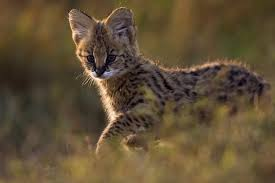

In [19]:
Image.open(os.path.join(os.path.join(test, 'cat'), os.listdir(os.path.join(test, 'cat'))[3]))

In [20]:
# Loading training and test data with standardized target size (180x180)

train_data = utils.image_dataset_from_directory(
    train,
    image_size= (180, 180),
    batch_size= 32,
    shuffle= True
)
test_data = utils.image_dataset_from_directory(
    test,
    image_size= (180, 180),
    batch_size= 32,
    shuffle= False
)
val_data = utils.image_dataset_from_directory(
    validation,
    image_size= (180, 180),
    batch_size= 32,
    shuffle= False
)

Found 464 files belonging to 5 classes.
Found 82 files belonging to 5 classes.
Found 83 files belonging to 5 classes.


#### Note: Data dataset is split into 464 training, 83 validation, and 82 testing samples. Images are resized to 180x180 pixels.

## Data Augmentation Strategy

#### Note: Applied horizontal flip, rotation (0.1), zoom (0.2), and contrast adjustments to prevent overfitting on the small dataset.

In [ ]:
data_augmentation = Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.1)
])

## CNN Model Architecture & Hyperparameters

#### Setup detail
- Activation: ReLU
- Output: Softmax
- Optimizer: Adam
- Loss: Sparse Categorical Crossentropy

In [41]:
model = Sequential([
    layers.Input((180,180,3)),
    data_augmentation,
    
    # Rescaling pixel values from [0, 255] to [0, 1]
    layers.Rescaling(1./255),

    # Conv Block 1
    layers.Conv2D(32, kernel_size=(3,3), padding= 'same', strides=(2,2), activation= 'relu'),
    layers.MaxPooling2D((2,2)),

    # Conv Block 2
    layers.Conv2D(64, kernel_size= (3,3), padding= 'same', strides=(2,2), activation= 'relu'),
    layers.MaxPooling2D((2,2)),

    # Conv Block 3
    layers.Conv2D(128, kernel_size= (3,3), padding= 'same', strides=(2,2), activation= 'relu'),
    layers.MaxPooling2D((2,2)),

    # Flattening features and applying dropout to reduce overfitting
    layers.Flatten(),
    layers.Dense(128, activation= 'relu'),
    layers.Dropout(0.5),
    layers.Dense(5, activation= 'softmax')]
)

model.compile(optimizer= 'adam', loss= 'sparse_categorical_crossentropy', metrics=['accuracy'])

# Model Training & Callbacks

In [42]:
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',     # Validation loss ko observe karega
    patience=10,              # Agar 5 epochs tak val_loss improve na ho toh training rokh dega
    restore_best_weights=True # Sab se behtar weights restore kar dega
)

checkpoint = callbacks.ModelCheckpoint(
    filepath='convert_from_scratch_with_augmentation.keras',
    save_best_only=True,
    monitor='val_loss'
)

In [43]:
history = model.fit(train_data, epochs= 100, validation_data= val_data, callbacks= [early_stopping, checkpoint]
)

Epoch 1/100


C:\Users\S.M. Abdullah\anaconda3\envs\tf_env\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 194ms/step - accuracy: 0.2241 - loss: 1.6162 - val_accuracy: 0.2048 - val_loss: 1.6176
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 163ms/step - accuracy: 0.2780 - loss: 1.5880 - val_accuracy: 0.2048 - val_loss: 1.5995
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 162ms/step - accuracy: 0.2565 - loss: 1.5800 - val_accuracy: 0.2289 - val_loss: 1.5775
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 133ms/step - accuracy: 0.2909 - loss: 1.5690 - val_accuracy: 0.2410 - val_loss: 1.5296
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.3233 - loss: 1.5174 - val_accuracy: 0.3012 - val_loss: 1.4760
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.3147 - loss: 1.4870 - val_accuracy: 0.3976 - val_loss: 1.4411
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step - accuracy: 0.3793 - loss: 1.4823 - val_accuracy: 0.4458 - val_loss: 1.3929
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 164ms/step - accuracy: 0.3879 - loss: 1.4508 - val_accuracy: 0.3976 -

# Training Performance Evaluation

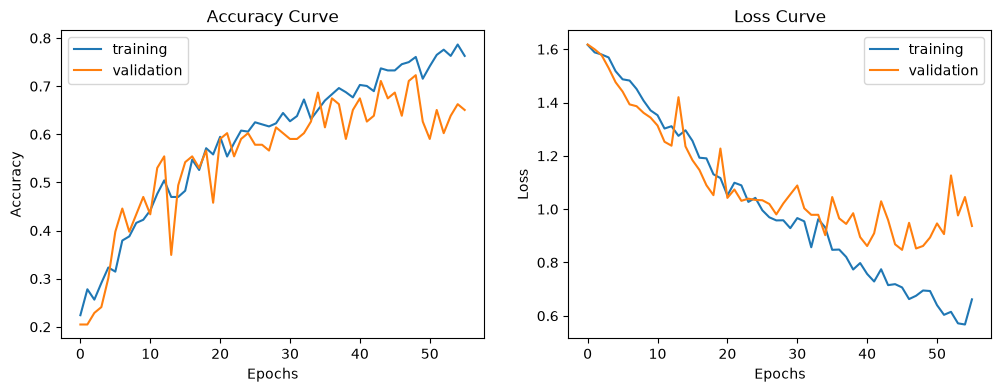

In [44]:
plt.figure(figsize=(12, 4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label = 'training')
plt.plot(history.history['val_accuracy'], label = 'validation')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label = 'training')
plt.plot(history.history['val_loss'], label = 'validation')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Model Testing & Evaluation

In [46]:
test_data_pred = model.predict(test_data)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


In [47]:
y_true = np.concatenate([y.numpy() for x, y in test_data], axis= 0)


print(classification_report(y_true, np.argmax(test_data_pred, axis= 1)))

              precision    recall  f1-score   support

           0       0.53      0.59      0.56        17
           1       0.79      0.69      0.73        16
           2       0.54      0.88      0.67        16
           3       0.33      0.12      0.18        16
           4       0.59      0.59      0.59        17

    accuracy                           0.57        82
   macro avg       0.55      0.57      0.55        82
weighted avg       0.55      0.57      0.55        82



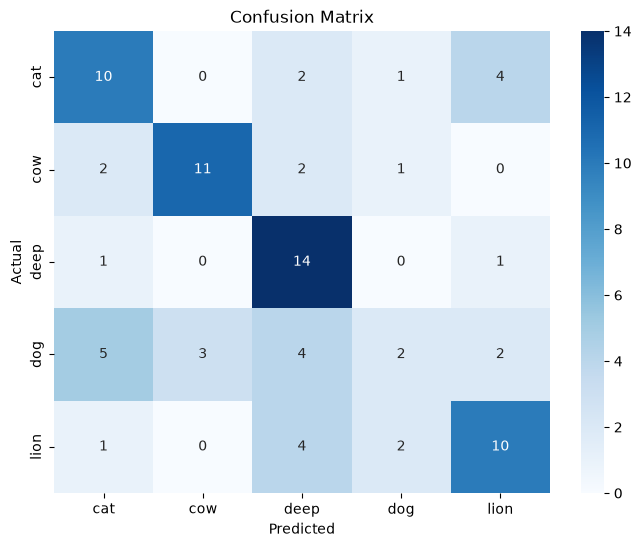

In [48]:
confusion = confusion_matrix(y_true, np.argmax(test_data_pred, axis= 1))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_data.class_names,
            yticklabels=test_data.class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Correct: 47
Not Correct 35


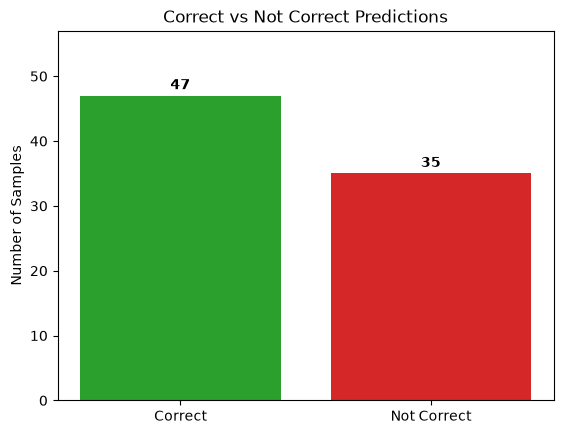

In [49]:
correct = 0
not_correct = 0

for i, j in zip(y_true, np.argmax(test_data_pred, axis= 1)):
    if i == j:
        correct+=1
    else:
        not_correct+=1

print('Correct:', correct)
print('Not Correct', not_correct)

categories = ['Correct', 'Not Correct']
counts = [correct, not_correct]

# Correct vs Not Correct plot mein exact counts dikhane ke liye
plt.bar(categories, counts, color=['#2ca02c', '#d62728'])
for i, v in enumerate(counts):
    plt.text(i, v + 1, str(v), ha='center', fontweight='bold')
plt.title('Correct vs Not Correct Predictions')
plt.ylabel('Number of Samples')
plt.ylim(0, max(counts) + 10)
plt.show()

## Save Model

In [50]:
import joblib

joblib.dump(model, 'animal_classification_model.pkl')
print("Model joblib ke zariye save ho gaya hai!")

Model joblib ke zariye save ho gaya hai!


# Evaluation & Conclusion

### Conclusion: The CNN model achieved 56% test accuracy. Confusion Matrix and classification report show decent performance on classes like 'lion' and 'cow', but some misclassification between visually similar classes.

In [21]:
# Testing model on usseen image

import gradio as gr
import tensorflow as tf
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array
import joblib

model = joblib.load('animal_classification_model.pkl')
def pred_image(img_path):
    # Image loading and preprocessing
    img # Testing model on usseen image= load_img(
        img_path, targ
                   et_size=(180, 180))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    
    # Model Prediction
    pred = model.predict(img_array)
    predicted_class = train_data.class_names[np.argmax(pred[0])]
    confidence = float(np.max(pred[0]))
    
    # Gradio Label format return karein
    return {predicted_class: confidence}

# Interface Launch
interface = gr.Interface(
    fn=pred_image,
    inputs=gr.Image(type="filepath"),
    outputs=gr.Label(num_top_classes=3),
    title="Animal Classification CNN"
)

interface.launch(share=False)

* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step


In [ ]:
%pip install gradio